# K-Mean clustering

In [3]:
pip install pyspark

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Cluster Centers: 
[3.77007299e+01 3.42262774e+04 4.74452555e-01]
[4.27837838e+01 1.25310811e+05 3.91891892e-01]
[3.56137566e+01 7.37301587e+04 5.39682540e-01]
Silhouette Score: 0.7654801652056317


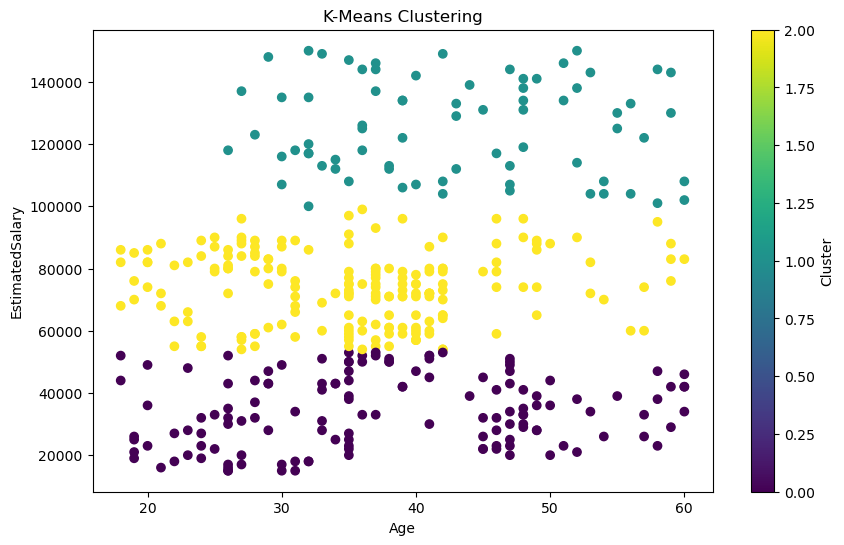

In [4]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("KMeansClustering").getOrCreate()

df = spark.read.csv(r"C:/Users/Sastra/Downloads/archive/Social_Network_Ads.csv", header=True, inferSchema=True)

gender_indexer = StringIndexer(inputCol="Gender", outputCol="GenderIndex")

assembler = VectorAssembler(inputCols=["Age", "EstimatedSalary", "GenderIndex"], outputCol="features")

df_transformed = gender_indexer.fit(df).transform(df)
df_transformed = assembler.transform(df_transformed)
df_features = df_transformed.select("features")

kmeans = KMeans(featuresCol="features", k=3) 
kmeans_model = kmeans.fit(df_features)

kmeans_predictions = kmeans_model.transform(df_features)

evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette", distanceMeasure="squaredEuclidean")
silhouette_score = evaluator.evaluate(kmeans_predictions)
centers = kmeans_model.clusterCenters()
print("Cluster Centers: ")
for center in centers:
    print(center)

print(f"Silhouette Score: {silhouette_score}")

kmeans_pandas = kmeans_predictions.select("features", "prediction").toPandas()
kmeans_pandas['Age'] = kmeans_pandas['features'].apply(lambda x: x[0])
kmeans_pandas['EstimatedSalary'] = kmeans_pandas['features'].apply(lambda x: x[1])
kmeans_pandas['GenderIndex'] = kmeans_pandas['features'].apply(lambda x: x[2])

plt.figure(figsize=(10, 6))
plt.scatter(kmeans_pandas['Age'], kmeans_pandas['EstimatedSalary'], c=kmeans_pandas['prediction'], cmap='viridis', marker='o')
plt.title('K-Means Clustering')
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.colorbar(label='Cluster')
plt.show()